# MP1 — Monolayer NbSe₂ phonon dispersion (the soft mode)

Companion to Mini-project 1, Stage 1. DFPT phonon dispersion of the
undistorted 1H-NbSe₂ along Γ–M–K–Γ (`nbse2.freq.gp`, from `ph.x`→`q2r.x`→`matdyn.x` on a 6×6×1 q-grid, k = 12×12×1, `degauss = 0.01`).
An **imaginary** branch (plotted negative) dives to ≈ **−71 cm⁻¹** near
**q$_{CDW}$ = (1/3,0) = ⅔ Γ–M** — the lattice instability that becomes the
3×3 CDW. Requires `numpy`, `matplotlib`.

deepest soft mode = -71.8 cm^-1  at path-x=0.361  (~2/3 of Gamma->M = q_CDW=(1/3,0))
directly-computed value at the q=(1/3,0) grid point: -70.6 cm^-1


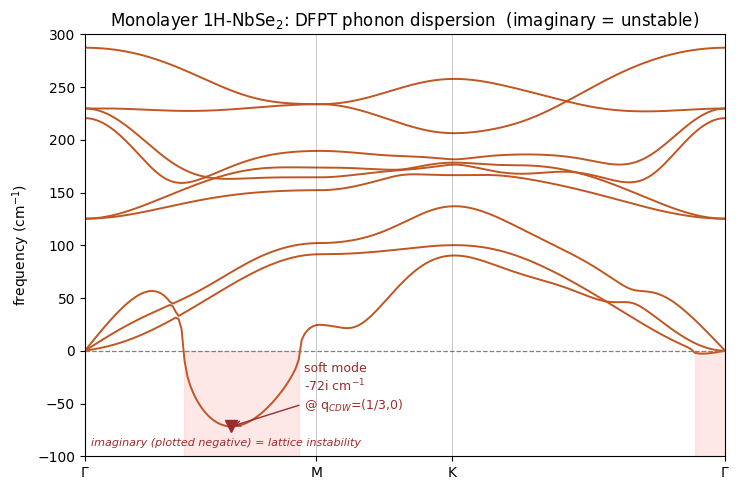

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

d = Path('../code/advanced/04-nbse2-cdw/ref')
D = np.loadtxt(d/'nbse2.freq.gp')
x = D[:, 0]; F = D[:, 1:]          # 9 branches, cm^-1

# path Gamma(80) -> M(50) -> K(80) -> Gamma(1)  => indices 0,79,129,210
iG1, iM, iK, iG2 = 0, 79, 129, 210
ticks  = [x[iG1], x[iM], x[iK], x[iG2]]
labels = [r'$\Gamma$', 'M', 'K', r'$\Gamma$']

# soft mode
imin = np.unravel_index(np.argmin(F), F.shape)
xmin, fmin = x[imin[0]], F.min()
print(f"deepest soft mode = {fmin:.1f} cm^-1  at path-x={xmin:.3f}  (~2/3 of Gamma->M = q_CDW=(1/3,0))")
print(f"directly-computed value at the q=(1/3,0) grid point: -70.6 cm^-1")

fig, ax = plt.subplots(figsize=(7.5, 5))
# shade the unstable (imaginary) region
low = F.min(axis=1)
ax.fill_between(x, -100, 0, where=(low < 0), color='#fed7d7', alpha=0.6, zorder=0)
for b in range(F.shape[1]):
    ax.plot(x, F[:, b], color='#c05621', lw=1.4)
ax.axhline(0, color='gray', ls='--', lw=0.9)
# mark q_CDW
ax.plot(xmin, fmin, 'v', color='#9b2c2c', ms=9, zorder=5)
ax.annotate(f'soft mode\n{fmin:.0f}i cm$^{{-1}}$\n@ q$_{{CDW}}$=(1/3,0)',
            xy=(xmin, fmin), xytext=(xmin+0.18, -55),
            color='#9b2c2c', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#9b2c2c'))
for t in ticks:
    ax.axvline(t, color='k', lw=0.5, alpha=0.3)
ax.set_xticks(ticks); ax.set_xticklabels(labels)
ax.set_xlim(x.min(), x.max()); ax.set_ylim(-100, 300)
ax.set_ylabel('frequency (cm$^{-1}$)')
ax.set_title('Monolayer 1H-NbSe$_2$: DFPT phonon dispersion  (imaginary = unstable)')
ax.text(0.015, -90, 'imaginary (plotted negative) = lattice instability',
        fontsize=8, color='#9b2c2c', style='italic')
fig.tight_layout()
fig.savefig('../static/img/MP1-nbse2-phonon.png', dpi=120)
plt.show()

**Read-off.** A whole branch is pushed **below zero** over a broad region
around q$_{CDW}$ = (1/3,0) — the deep, extended **Kohn anomaly** characteristic
of NbSe₂. The directly-computed dynamical matrix at that grid point gives
−70.6 cm⁻¹ (imaginary), matching the interpolated dispersion. This is the
unambiguous DFT fingerprint of the charge-density-wave instability: the
high-symmetry cell is **not** the ground state. The acoustic modes return to
≈0 at Γ (the acoustic sum rule), so the instability is genuinely at finite q,
not a Γ artefact. Next (Stage 2): freeze this mode into a 3×3 supercell and
relax to the distorted CDW ground state.